In [ ]:
#import pandas library
import pandas as pd

#load dataset
df3 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/HDHI Admission data.csv")
df3.head()

,SNO,MRD No.,D.O.A,D.O.D,AGE,GENDER,RURAL,TYPE OF ADMISSION-EMERGENCY/OPD,month year,DURATION OF STAY,...,CONGENITAL,UTI,NEURO CARDIOGENIC SYNCOPE,ORTHOSTATIC,INFECTIVE ENDOCARDITIS,DVT,CARDIOGENIC SHOCK,SHOCK,PULMONARY EMBOLISM,CHEST INFECTION
0,1,234735,4/1/2017,4/3/2017,81,M,R,E,Apr-17,3,...,0,0,0,0,0,0,0,0,0,0
1,2,234696,4/1/2017,4/5/2017,65,M,R,E,Apr-17,5,...,0,0,0,0,0,0,0,0,0,0
2,3,234882,4/1/2017,4/3/2017,53,M,U,E,Apr-17,3,...,0,0,0,0,0,0,0,0,0,0
3,4,234635,4/1/2017,4/8/2017,67,F,U,E,Apr-17,8,...,0,0,0,0,0,0,0,0,0,0
4,5,234486,4/1/2017,4/23/2017,60,F,U,E,Apr-17,23,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
#standardise column names
df3.columns = (
    df3.columns
      .str.strip()
      .str.lower()
      .str.replace(r'[^a-zA-Z0-9]+', '_', regex=True)
      .str.replace('_+', '_', regex=True)
      .str.rstrip('_')
)

df3.columns

Index(['sno', 'mrd_no', 'd_o_a', 'd_o_d', 'age', 'gender', 'rural',
       'type_of_admission_emergency_opd', 'month_year', 'duration_of_stay',
       'duration_of_intensive_unit_stay', 'outcome', 'smoking', 'alcohol',
       'dm', 'htn', 'cad', 'prior_cmp', 'ckd', 'hb', 'tlc', 'platelets',
       'glucose', 'urea', 'creatinine', 'bnp', 'raised_cardiac_enzymes', 'ef',
       'severe_anaemia', 'anaemia', 'stable_angina', 'acs', 'stemi',
       'atypical_chest_pain', 'heart_failure', 'hfref', 'hfnef', 'valvular',
       'chb', 'sss', 'aki', 'cva_infract', 'cva_bleed', 'af', 'vt', 'psvt',
       'congenital', 'uti', 'neuro_cardiogenic_syncope', 'orthostatic',
       'infective_endocarditis', 'dvt', 'cardiogenic_shock', 'shock',
       'pulmonary_embolism', 'chest_infection'],
      dtype='object')

In [ ]:
#import numpy library
import numpy as np

#initial inspection
df3.info()
df3.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15757 entries, 0 to 15756
Data columns (total 56 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   sno                              15757 non-null  int64 
 1   mrd_no                           15757 non-null  object
 2   d_o_a                            15757 non-null  object
 3   d_o_d                            15757 non-null  object
 4   age                              15757 non-null  int64 
 5   gender                           15757 non-null  object
 6   rural                            15757 non-null  object
 7   type_of_admission_emergency_opd  15757 non-null  object
 8   month_year                       15757 non-null  object
 9   duration_of_stay                 15757 non-null  int64 
 10  duration_of_intensive_unit_stay  15757 non-null  int64 
 11  outcome                          15757 non-null  object
 12  smoking                         

,sno,mrd_no,d_o_a,d_o_d,age,gender,rural,type_of_admission_emergency_opd,month_year,duration_of_stay,...,congenital,uti,neuro_cardiogenic_syncope,orthostatic,infective_endocarditis,dvt,cardiogenic_shock,shock,pulmonary_embolism,chest_infection
14089,14090,408615,27/01/2019,28/01/2019,50,M,U,E,Jan-19,2,...,0,0,0,0,0,0,0,0,0,0
11327,11328,597843,09/10/2018,10/10/2018,36,M,U,E,Oct-18,2,...,0,0,0,0,0,0,0,0,0,0
14984,14985,679516,27/02/2019,14/03/2019,64,F,U,E,Feb-19,16,...,0,0,0,0,0,0,0,0,0,0
4910,4911,179856,12/4/2017,12/12/2017,55,F,U,O,Dec-17,9,...,0,0,0,0,0,0,0,0,0,0
4228,4229,384426,11/8/2017,11/9/2017,64,M,U,E,Nov-17,2,...,0,0,0,0,0,0,1,1,0,0


In [ ]:
#covert date columns to UK format
df3['d_o_a'] = pd.to_datetime(df3['d_o_a'], dayfirst=True, errors='coerce')
df3['d_o_d'] = pd.to_datetime(df3['d_o_d'], dayfirst=True, errors='coerce')
df3['month_year'] = pd.to_datetime(df3['month_year'], format='%b-%y', errors='coerce')


In [ ]:
#covert categorical fields
df3['gender'] = df3['gender'].astype('category')
df3['rural'] = df3['rural'].astype('category')
df3['type_of_admission_emergency_opd'] = df3['type_of_admission_emergency_opd'].astype('category')
df3['outcome'] = df3['outcome'].astype('category')

# MRD number should remain string (ID field)
df3['mrd_no'] = df3['mrd_no'].astype(str)


In [ ]:
#convert lab values to numeric
lab_cols = [
    'hb','tlc','platelets','glucose','urea','creatinine','bnp','ef'
]

for col in lab_cols:
    df3[col] = pd.to_numeric(df3[col], errors='coerce')


In [ ]:
#fix chest infection data & data type
df3['chest_infection'] = (
    df3['chest_infection']
      .astype(str)
      .str.strip()
      .replace({'Yes': 1, 'No': 0})
)

df3['chest_infection'] = pd.to_numeric(df3['chest_infection'], errors='coerce').fillna(0).astype(int)


In [ ]:
#check for missing values
df3.isna().sum()

,0
sno,0
mrd_no,0
d_o_a,3767
d_o_d,3770
age,0
gender,0
rural,0
type_of_admission_emergency_opd,0
month_year,0
duration_of_stay,0


In [ ]:
#drop rows missing both admission & discharge dates
df3 = df3.dropna(subset=['d_o_a', 'd_o_d'], how='all')


In [ ]:
#add missingness indicators for rows with one missing date
df3['missing_doa'] = df3['d_o_a'].isna().astype(int)
df3['missing_dod'] = df3['d_o_d'].isna().astype(int)

In [ ]:
#impute lab values with median
lab_cols = ['hb','tlc','platelets','glucose','urea','creatinine','ef']

for col in lab_cols:
    df3[col] = df3[col].fillna(df3[col].median())


In [ ]:
#add missingness indicator to BNP
#too high to drop or impute
df3['bnp_missing'] = df3['bnp'].isna().astype(int)
df3['bnp'] = pd.to_numeric(df3['bnp'], errors='coerce')


In [ ]:
#standardise categorical labels for clarity
df3['gender'] = df3['gender'].map({'M': 'Male', 'F': 'Female'})
df3['rural'] = df3['rural'].map({'R': 'Rural', 'U': 'Urban'})
df3['type_of_admission_emergency_opd'] = df3['type_of_admission_emergency_opd'].map({
    'E': 'Emergency',
    'O': 'OPD'
})

In [ ]:
#validate duration of stay
df3['computed_stay'] = (df3['d_o_d'] - df3['d_o_a']).dt.days
df3['stay_mismatch'] = df3['computed_stay'] != df3['duration_of_stay']

#inspect mismatches
df3[df3['stay_mismatch'] == True].head()


,sno,mrd_no,d_o_a,d_o_d,age,gender,rural,type_of_admission_emergency_opd,month_year,duration_of_stay,...,dvt,cardiogenic_shock,shock,pulmonary_embolism,chest_infection,missing_doa,missing_dod,bnp_missing,computed_stay,stay_mismatch
0,1,234735,2017-01-04,2017-03-04,81,Male,Rural,Emergency,2017-04-01,3,...,0,0,0,0,0,0,0,0,59.0,True
1,2,234696,2017-01-04,2017-05-04,65,Male,Rural,Emergency,2017-04-01,5,...,0,0,0,0,0,0,0,1,120.0,True
2,3,234882,2017-01-04,2017-03-04,53,Male,Urban,Emergency,2017-04-01,3,...,0,0,0,0,0,0,0,0,59.0,True
3,4,234635,2017-01-04,2017-08-04,67,Female,Urban,Emergency,2017-04-01,8,...,0,0,0,0,0,0,0,1,212.0,True
4,5,234486,2017-01-04,NaT,60,Female,Urban,Emergency,2017-04-01,23,...,0,0,0,0,0,0,1,0,NaN,True


In [ ]:
#remove duplicates
df3 = df3.drop_duplicates(subset=['mrd_no', 'd_o_a'])

In [ ]:
#detect outliers in numeric columns
numeric_cols = df3.select_dtypes(include=[np.number]).columns

#IQR function
def detect_outliers_iqr(data, cols):
    outlier_summary = {}

    for col in cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]

        outlier_summary[col] = {
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'num_outliers': outliers.shape[0]
        }

    return pd.DataFrame(outlier_summary).T

#run outlier detection
outlier_report = detect_outliers_iqr(df3, numeric_cols)
outlier_report

,lower_bound,upper_bound,num_outliers
sno,-5724.750,22979.250,0.0
age,30.000,94.000,267.0
duration_of_stay,-4.500,15.500,584.0
duration_of_intensive_unit_stay,-5.000,11.000,547.0
smoking,0.000,0.000,585.0
alcohol,0.000,0.000,757.0
dm,-1.500,2.500,0.0
htn,-1.500,2.500,0.0
cad,-1.500,2.500,0.0
prior_cmp,0.000,0.000,1737.0


In [ ]:
#export cleaned dataset
df3.to_csv("cleaned_hospital_data.csv", index=False)
print("Final shape:", df3.shape)


Final shape: (11738, 61)


In [ ]:
#import libraries for EDA
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [ ]:
#display settings
#makes plots cleaner
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


In [ ]:
#monthly admissions trend
#interactive line chart
#seasonal patterns, peaks, collapses, operational surges

monthly = df3.groupby('month_year').size().reset_index(name='admissions')

fig = px.line(monthly, x='month_year', y='admissions',
              title='Monthly Admissions Trend', markers=True)
fig.show()


In [ ]:
#emergency vs OPD admissions over time
#interactive line chart
#differences in demand streams, parallel trends, seasonal divergence
adm_type = df3.groupby(['month_year','type_of_admission_emergency_opd']).size().reset_index(name='count')

fig = px.line(adm_type, x='month_year', y='count',
              color='type_of_admission_emergency_opd',
              title='Emergency vs OPD Admissions Over Time')

fig.update_layout(
    legend_title_text='Admission Type',
    legend=dict(
        x=0.30, #move to left
        y=0.98, #move to top
        xanchor='right',
        yanchor='top',
        font=dict(size=10) #adjust legend text size
    )
)

fig.show()


/tmp/ipykernel_744/3310171682.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [ ]:
#rolling average trend
#interactive line chart
#underlying trend, removes noise
monthly['rolling'] = monthly['admissions'].rolling(3).mean()

fig = px.line(monthly, x='month_year', y='rolling',
              title='3-Month Rolling Average of Admissions')

fig.show()


In [ ]:
#age distribution of patients
#histogram + box + KDE
#age skew, dominant age groups, clinical demographics
fig = px.histogram(df3, x='age', nbins=40, marginal='box',
                   title='Age Distribution of Patients')
fig.show()


In [ ]:
#biomarker distributions
#three-panel interactive boxplots
#outliers, variability, severity patterns
import plotly.subplots as sp
import plotly.graph_objects as go

#define biomarker groups
group1 = ['creatinine', 'hb', 'ef']
group2 = ['glucose', 'urea']
group3 = ['bnp']

#create 3-panel subplot layout
fig = sp.make_subplots(
    rows=1, cols=3,
    subplot_titles=("Creatinine, HB, EF", "Glucose & Urea", "BNP"),
    horizontal_spacing=0.08
)

#panel 1 – creatinine, hb, ef
for col in group1:
    fig.add_trace(go.Box(y=df3[col], name=col), row=1, col=1)

#panel 2 – glucose, urea
for col in group2:
    fig.add_trace(go.Box(y=df3[col], name=col), row=1, col=2)

#panel 3 – BNP only
fig.add_trace(go.Box(y=df3['bnp'], name='bnp'), row=1, col=3)

#layout adjustments
fig.update_layout(
    title="Distribution of Key Biomarkers",
    showlegend=False,
    height=500,
    width=1200
)

fig.show()


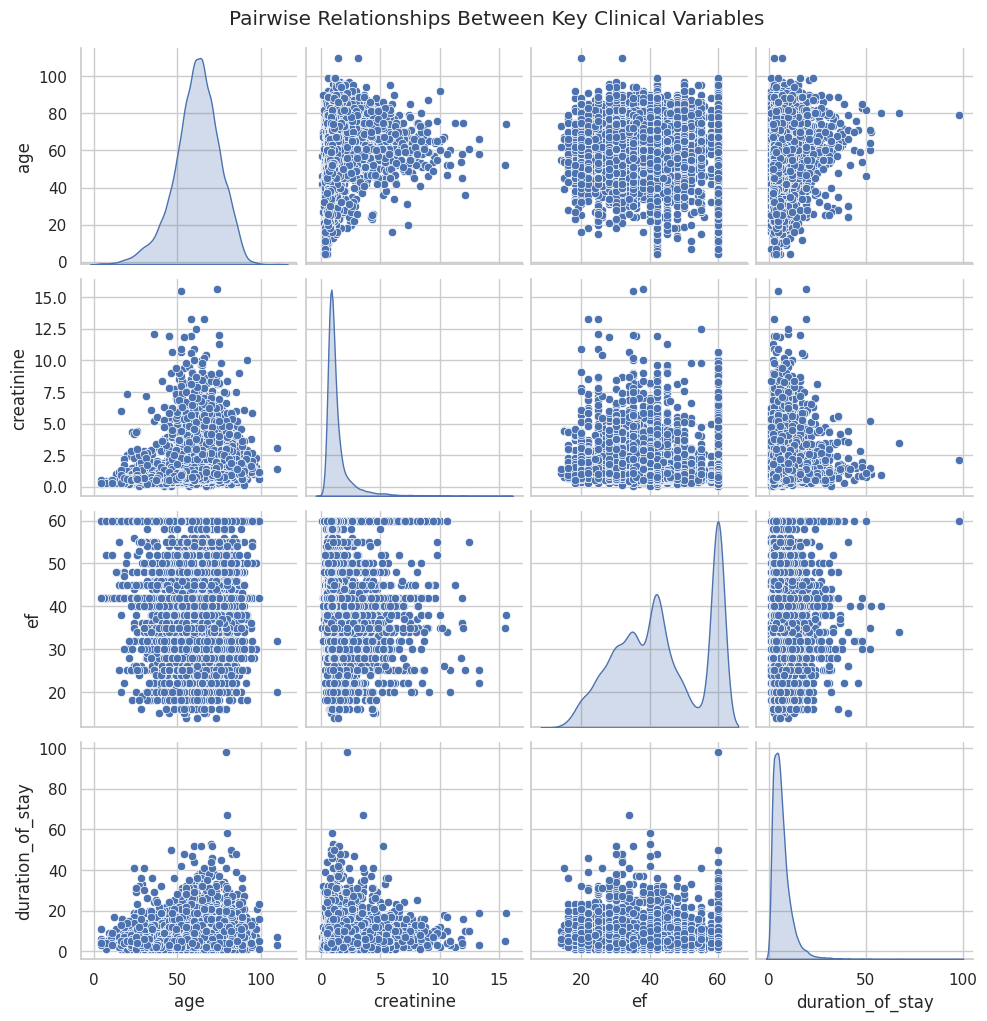

In [ ]:
#pairplot of clinical variables
#advanced relationship exploration
#non-linear relationships, clusters, spread
sns.pairplot(
    df3[['age', 'creatinine', 'ef', 'duration_of_stay']],
    diag_kind='kde',
)
plt.suptitle('Pairwise Relationships Between Key Clinical Variables', y=1.02)
plt.show()


In [ ]:
#most common diagnoses
#interactive bar chart
#high-burden conditions, resource-intensive diagnoses
diagnosis_cols = ['acs','heart_failure','aki','stemi','valvular','cva_infract']

diag_counts = df3[diagnosis_cols].sum().reset_index()
diag_counts.columns = ['diagnosis','count']

fig = px.bar(diag_counts, x='diagnosis', y='count',
             title='Most Common Diagnoses')
fig.show()


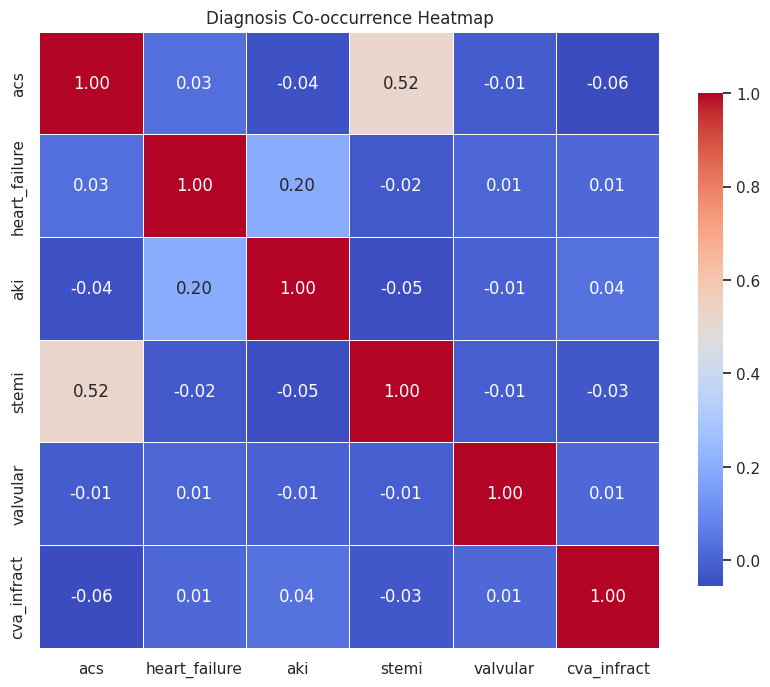

In [ ]:
#diagnosis co-occurrence
#clustered heatmap
#comorbidity patterns, clinical overlap
plt.figure(figsize=(10,8))
sns.heatmap(
    df3[diagnosis_cols].corr(),
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
    )
plt.title('Diagnosis Co-occurrence Heatmap')
plt.show()

In [ ]:
#duration of stay by admission type
#interactive violin plot
#severity differences, variability, LOS patterns
fig = px.violin(
    df3,
    x='type_of_admission_emergency_opd',
    y='duration_of_stay',
    box=True,          #adds a mini boxplot inside
    points='all',      #shows individual points
    title='Duration of Stay by Admission Type'
)

fig.show()

In [ ]:
#patient outcomes distribution
#interactive bar chart
#mortality, DAMA, discharge patterns
outcome_counts = df3['outcome'].value_counts().reset_index()
outcome_counts.columns = ['outcome','count']

fig = px.bar(outcome_counts, x='outcome', y='count',
             title='Distribution of Patient Outcomes')
fig.show()


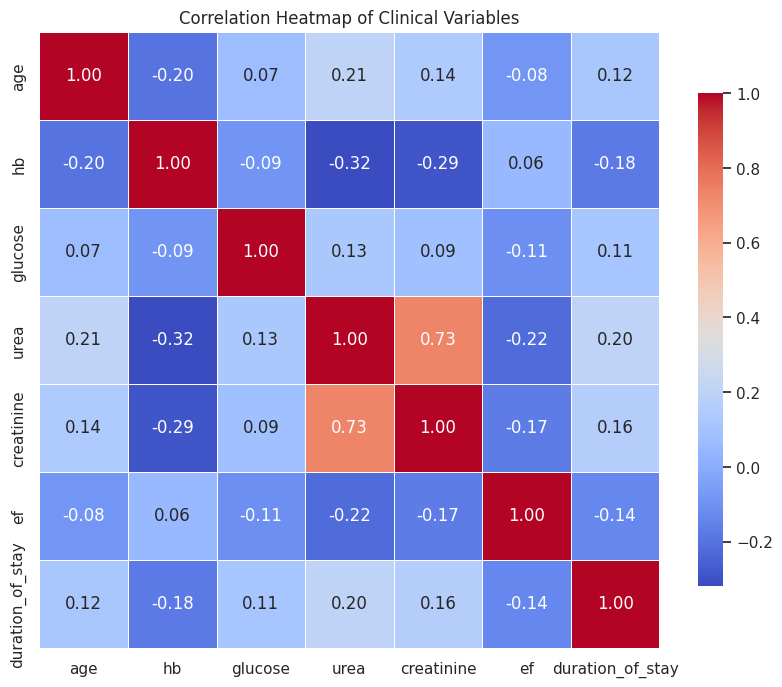

In [ ]:
#key numeric clinical variables
#correlation heatmap
#strong renal correlations, weak LOS correlations
num_cols = ['age','hb','glucose','urea','creatinine','ef','duration_of_stay']

plt.figure(figsize=(10,8))
sns.heatmap(
    df3[num_cols].corr(),
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
    )
plt.title('Correlation Heatmap of Clinical Variables')
plt.show()

In [ ]:
#k-means clusters of clinical profiles
#interactive scatter plot
#patient subtypes, severity groups, clinical segmentation
from sklearn.cluster import KMeans

X = df3[['creatinine','ef']].dropna()
kmeans = KMeans(n_clusters=3, random_state=42).fit(X)
df3.loc[X.index, 'cluster'] = kmeans.labels_

fig = px.scatter(df3, x='creatinine', y='ef', color='cluster',
                 title='K-Means Clusters of Clinical Profiles')
fig.show()


In [ ]:
#imports & setup for ML
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


In [ ]:
#define target and feature sets
target_col = 'duration_of_stay' #resource use via length of stay

leakage_cols = [
    'sno', 'mrd_no', 'd_o_a', 'd_o_d', 'month_year', 'outcome', 'computed_stay',
    'stay_mismatch', 'cluster', 'duration_of_intensive_unit_stay'
] #columns that should not be used as predictors

feature_cols = [c for c in df3.columns if c not in leakage_cols + [target_col]]

X = df3[feature_cols].copy()
y = df3[target_col].copy()


In [ ]:
#identify numeric and categorical features
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['age', 'smoking', 'alcohol', 'dm', 'htn', 'cad', 'prior_cmp', 'ckd', 'hb', 'tlc', 'platelets', 'glucose', 'urea', 'creatinine', 'bnp', 'raised_cardiac_enzymes', 'ef', 'severe_anaemia', 'anaemia', 'stable_angina', 'acs', 'stemi', 'atypical_chest_pain', 'heart_failure', 'hfref', 'hfnef', 'valvular', 'chb', 'sss', 'aki', 'cva_infract', 'cva_bleed', 'af', 'vt', 'psvt', 'congenital', 'uti', 'neuro_cardiogenic_syncope', 'orthostatic', 'infective_endocarditis', 'dvt', 'cardiogenic_shock', 'shock', 'pulmonary_embolism', 'chest_infection', 'missing_doa', 'missing_dod', 'bnp_missing']
Categorical features: ['gender', 'rural', 'type_of_admission_emergency_opd']


In [ ]:
#train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
#scaling + one-hot encoding
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


In [ ]:
#define multiple models to compare
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingRegressor(
        random_state=42
    )
}


In [ ]:
#train models & evaluate test data
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', model)
    ]) #fits each model

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test) #predicts LOS

    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred) #computes MAE, RMSE, r2

    results.append({
        'model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'pipeline': pipe
    })

results_df = pd.DataFrame(results).drop(columns=['pipeline'])
results_df #stores in comparison table


,model,MAE,RMSE,R2
0,LinearRegression,2.869449,4.523838,0.186935
1,RandomForest,2.900568,4.540000,0.181115
2,GradientBoosting,2.872158,4.517051,0.189373


In [ ]:
#model performance comparison
#interactive bar chart
#visualise regression metrics
metrics_melted = results_df.melt(
    id_vars='model',
    value_vars=['MAE','RMSE','R2'],
    var_name='metric',
    value_name='value'
)

fig = px.bar(
    metrics_melted,
    x='model',
    y='value',
    color='metric',
    barmode='group',
    title='Model Performance Comparison (Regression Metrics)',
    text_auto='.3f'
)
fig.show()


In [ ]:
#true vs predicted
#interactive scatter
#how well the model fits across the LOS range
best_row = max(results, key=lambda x: x['R2'])
best_name = best_row['model']
best_pipe = best_row['pipeline']

y_pred_best = best_pipe.predict(X_test)

fig = px.scatter(
    x=y_test,
    y=y_pred_best,
    labels={'x': 'Actual LOS', 'y': 'Predicted LOS'},
    title=f'True vs Predicted Duration of Stay — {best_name}',
    opacity=0.5
)

fig.add_shape(
    type='line',
    x0=y_test.min(), y0=y_test.min(),
    x1=y_test.max(), y1=y_test.max(),
    line=dict(color='red', dash='dash')
)

fig.show()


In [ ]:
#residual distribution
#interactive histogram
#bias, skew, and model error structure
residuals = y_test - y_pred_best

fig = px.histogram(
    residuals,
    nbins=40,
    title=f'Residual Distribution — {best_name}',
    labels={'value': 'Residual (Actual - Predicted)'},
    opacity=0.75
)
fig.show()


In [ ]:
#feature importance
#interactive bar chart
#only for tree-based models
import numpy as np
import pandas as pd
import plotly.express as px

#extract the trained model from the best pipeline
model = best_pipe.named_steps['model']

#proceed if the model supports feature importance
if hasattr(model, "feature_importances_"):

    #get feature names after preprocessing
    ohe = best_pipe.named_steps['preprocess'].named_transformers_['cat'].named_steps['onehot']
    cat_names = ohe.get_feature_names_out(categorical_features)

    #combine numeric + categorical names
    feature_names = np.concatenate([numeric_features, cat_names])

    #clean long one-hot encoded labels
    clean_feature_names = []
    for name in feature_names:
        if name.startswith("type_of_admission_emergency_opd_"):
            short = name.replace("type_of_admission_emergency_opd_", "admission_")
            clean_feature_names.append(short)
        else:
            clean_feature_names.append(name)

    #build dataframe
    importances = model.feature_importances_

    fi_df = pd.DataFrame({
        'feature': clean_feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False)

    #plot bar chart
    fig = px.bar(
        fi_df.head(20),
        x='importance',
        y='feature',
        orientation='h',
        title=f"Top 20 Feature Importances — {best_name}",
        labels={'importance': 'Importance', 'feature': 'Feature'}
    )

    fig.update_layout(
        yaxis={'categoryorder': 'total ascending'},
        height=700
    )

    fig.show()
